In [2]:
sequence="ATGCGATCGATCGATCG"
print(sequence)


ATGCGATCGATCGATCG


In [3]:
# Bioinformatics Sequence Analyzer - Version 1

sequence = "ATGCGATCGATCGATCG"

print("DNA Sequence:", sequence)
print("Sequence Length:", len(sequence))

print("\nNucleotide Composition:")
print("A:", sequence.count("A"))
print("T:", sequence.count("T"))
print("G:", sequence.count("G"))
print("C:", sequence.count("C"))

gc_content = ((sequence.count("G") + sequence.count("C")) / len(sequence)) * 100
at_content = ((sequence.count("A") + sequence.count("T")) / len(sequence)) * 100

print("\nGC Content:", round(gc_content, 2), "%")
print("AT Content:", round(at_content, 2), "%")

DNA Sequence: ATGCGATCGATCGATCG
Sequence Length: 17

Nucleotide Composition:
A: 4
T: 4
G: 5
C: 4

GC Content: 52.94 %
AT Content: 47.06 %


In [4]:
valid_bases = set("ATGC")

if set(sequence).issubset(valid_bases):
    print("Valid DNA sequence")
else:
    print("Invalid DNA sequence")

Valid DNA sequence


In [5]:
user_sequence = input("Enter a DNA sequence: ").upper()

if set(user_sequence).issubset(set("ATGC")):
    print("✅ Valid DNA sequence")
else:
    print("❌ Invalid DNA sequence")

Enter a DNA sequence: ATGCGATCGATCG
✅ Valid DNA sequence


In [6]:
print("\n--- DNA Sequence Analysis ---")

print("Sequence:", user_sequence)
print("Length:", len(user_sequence))

print("\nNucleotide Composition:")
print("A:", user_sequence.count("A"))
print("T:", user_sequence.count("T"))
print("G:", user_sequence.count("G"))
print("C:", user_sequence.count("C"))

gc_content = ((user_sequence.count("G") + user_sequence.count("C")) / len(user_sequence)) * 100

print("\nGC Content:", round(gc_content, 2), "%")


--- DNA Sequence Analysis ---
Sequence: ATGCGATCGATCG
Length: 13

Nucleotide Composition:
A: 3
T: 3
G: 4
C: 3

GC Content: 53.85 %


In [7]:
at_content = ((user_sequence.count("A") + user_sequence.count("T")) / len(user_sequence)) * 100

print("AT Content:", round(at_content, 2), "%")

AT Content: 46.15 %


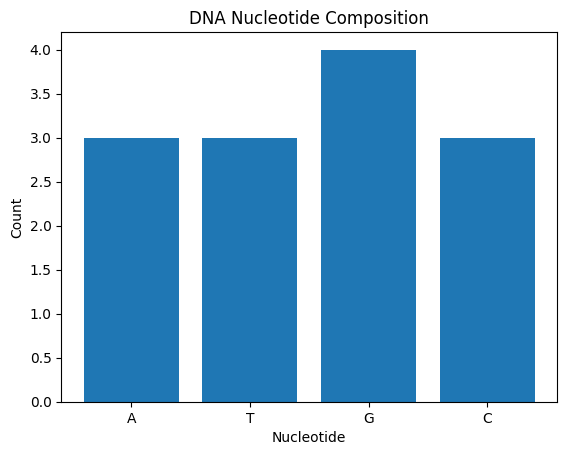

In [8]:
import matplotlib.pyplot as plt

bases = ["A", "T", "G", "C"]
counts = [
    user_sequence.count("A"),
    user_sequence.count("T"),
    user_sequence.count("G"),
    user_sequence.count("C")
]

plt.bar(bases, counts)
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.title("DNA Nucleotide Composition")
plt.show()

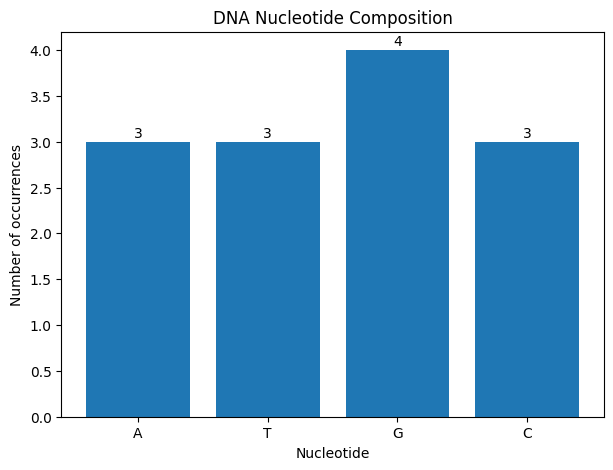

In [9]:
plt.figure(figsize=(7, 5))

plt.bar(bases, counts)

plt.xlabel("Nucleotide")
plt.ylabel("Number of occurrences")
plt.title("DNA Nucleotide Composition")

for i, count in enumerate(counts):
    plt.text(i, count + 0.05, str(count), ha="center")

plt.show()

In [11]:
from google.colab import files

uploaded = files.upload()

Saving sequence (1).fasta to sequence (1).fasta


In [12]:
filename = list(uploaded.keys())[0]

with open(filename, "r") as file:
    lines = file.readlines()

header = lines[0].strip()
sequence = "".join(lines[1:]).replace("\n", "").upper()

print("Header:", header)
print("Sequence length:", len(sequence))

Header: >NC_000017.11:c43170327-43044295 Homo sapiens chromosome 17, GRCh38.p14 Primary Assembly
Sequence length: 126033


In [13]:
print("\n--- DNA Sequence Analysis ---")

print("Sequence length:", len(sequence))

A = sequence.count("A")
T = sequence.count("T")
G = sequence.count("G")
C = sequence.count("C")

print("\nNucleotide Composition:")
print("A:", A)
print("T:", T)
print("G:", G)
print("C:", C)

gc_content = ((G + C) / len(sequence)) * 100
at_content = ((A + T) / len(sequence)) * 100

print("\nGC Content:", round(gc_content, 2), "%")
print("AT Content:", round(at_content, 2), "%")


--- DNA Sequence Analysis ---
Sequence length: 126033

Nucleotide Composition:
A: 35147
T: 35309
G: 28369
C: 27208

GC Content: 44.1 %
AT Content: 55.9 %


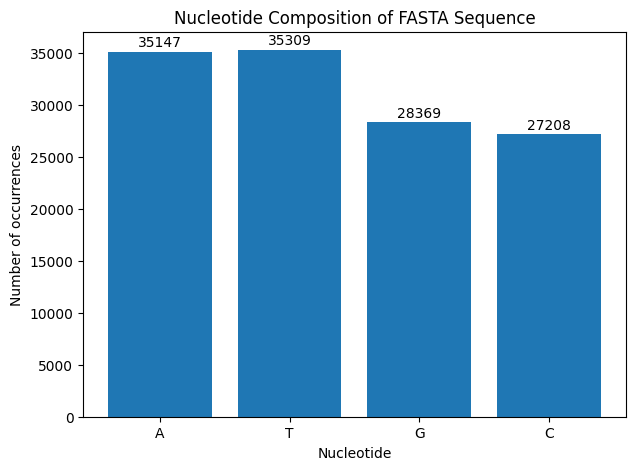

In [29]:
import matplotlib.pyplot as plt

bases = ["A", "T", "G", "C"]
counts = [A, T, G, C]

plt.figure(figsize=(7, 5))
plt.bar(bases, counts)

plt.xlabel("Nucleotide")
plt.ylabel("Number of occurrences")
plt.title("Nucleotide Composition of FASTA Sequence")

for i, count in enumerate(counts):
    plt.text(i, count + 500, str(count), ha="center")

plt.show()

In [16]:
window_size = 1000

gc_values = []

for i in range(0, len(sequence), window_size):
    window = sequence[i:i + window_size]

    if len(window) > 0:
        gc = (window.count("G") + window.count("C")) / len(window) * 100
        gc_values.append(gc)

print("Number of windows:", len(gc_values))
print("First 5 GC% values:", [round(x, 2) for x in gc_values[:5]])

Number of windows: 127
First 5 GC% values: [56.4, 48.1, 43.4, 49.6, 32.0]


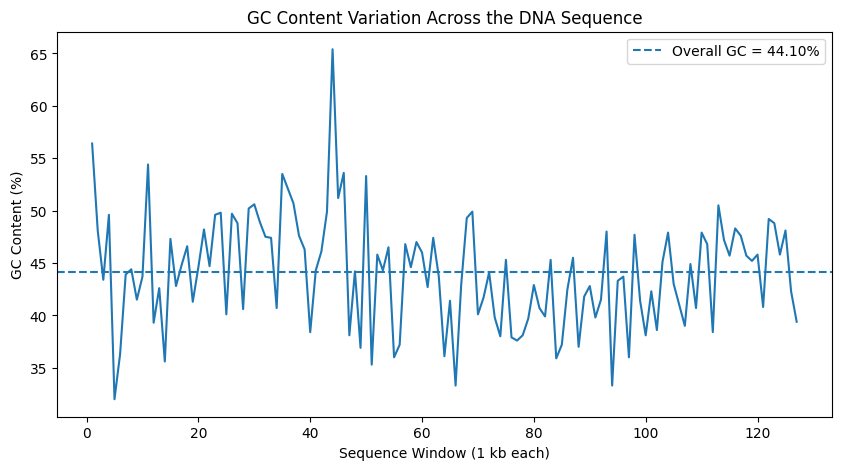

In [30]:
import matplotlib.pyplot as plt

positions = range(1, len(gc_values) + 1)

plt.figure(figsize=(10, 5))
plt.plot(positions, gc_values)

plt.xlabel("Sequence Window (1 kb each)")
plt.ylabel("GC Content (%)")
plt.title("GC Content Variation Across the DNA Sequence")

plt.axhline(gc_content, linestyle="--", label=f"Overall GC = {gc_content:.2f}%")
plt.legend()

plt.show()

In [18]:
motif = "ATG"

positions = []

start = 0

while True:
    position = sequence.find(motif, start)

    if position == -1:
        break

    positions.append(position + 1)
    start = position + 1

print("Motif searched:", motif)
print("Number of occurrences:", len(positions))
print("First 20 positions:", positions[:20])

Motif searched: ATG
Number of occurrences: 1891
First 20 positions: [251, 306, 336, 609, 657, 669, 817, 838, 870, 917, 1168, 1176, 1209, 1323, 1338, 1361, 1441, 1562, 1728, 1816]


In [19]:
motif = input("Enter a DNA motif to search: ").upper()

positions = []
start = 0

while True:
    position = sequence.find(motif, start)

    if position == -1:
        break

    positions.append(position + 1)
    start = position + 1

print("\nMotif:", motif)
print("Number of occurrences:", len(positions))
print("First 20 positions:", positions[:20])

Enter a DNA motif to search: TATA

Motif: TATA
Number of occurrences: 588
First 20 positions: [843, 1163, 1165, 1582, 2195, 2316, 2798, 2816, 3929, 4306, 4404, 4506, 4508, 4518, 4621, 4623, 4637, 4762, 4790, 4848]


In [20]:
complement = {
    "A": "T",
    "T": "A",
    "G": "C",
    "C": "G"
}

reverse_complement = "".join(complement[base] for base in sequence[::-1])

print("Original sequence (first 50 bases):")
print(sequence[:50])

print("\nReverse complement (first 50 bases):")
print(reverse_complement[:50])

Original sequence (first 50 bases):
CTTTCTGTCCCGCCCTTCCTCTGACTGTGTCTTGATTTCCTATTCTGAGA

Reverse complement (first 50 bases):
TGGAAGTGTTTGCTACCAAGTTTATTTGCAGTGTTAACAGCACAACATTT


In [21]:
stop_codons = ["TAA", "TAG", "TGA"]

orfs = []

for i in range(len(sequence) - 2):
    if sequence[i:i+3] == "ATG":
        for j in range(i + 3, len(sequence) - 2, 3):
            codon = sequence[j:j+3]

            if codon in stop_codons:
                orfs.append({
                    "start": i + 1,
                    "end": j + 3,
                    "length": j + 3 - i,
                    "sequence": sequence[i:j+3]
                })
                break

print("Number of ORFs found:", len(orfs))

print("\nFirst 5 ORFs:")
for orf in orfs[:5]:
    print(
        "Start:", orf["start"],
        "| End:", orf["end"],
        "| Length:", orf["length"]
    )

Number of ORFs found: 1891

First 5 ORFs:
Start: 251 | End: 460 | Length: 210
Start: 306 | End: 314 | Length: 9
Start: 336 | End: 362 | Length: 27
Start: 609 | End: 638 | Length: 30
Start: 657 | End: 713 | Length: 57


In [22]:
genetic_code = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G'
}

def translate(dna):
    protein = ""

    for i in range(0, len(dna) - 2, 3):
        codon = dna[i:i+3]
        amino_acid = genetic_code[codon]

        if amino_acid == "*":
            break

        protein += amino_acid

    return protein


print("Protein translations of first 5 ORFs:\n")

for number, orf in enumerate(orfs[:5], 1):
    protein = translate(orf["sequence"])

    print("ORF", number)
    print("DNA length:", orf["length"])
    print("Protein:", protein)
    print("Protein length:", len(protein))
    print()

Protein translations of first 5 ORFs:

ORF 1
DNA length: 210
Protein: MASVSQLACIYSALILQDYEVTFTEDKINALIKAASVNIETFWPGLFAKVLANVNIGSHICSVEGGKKT
Protein length: 69

ORF 2
DNA length: 9
Protein: MR
Protein length: 2

ORF 3
DNA length: 27
Protein: MPLLKQPV
Protein length: 8

ORF 4
DNA length: 30
Protein: MLRGTGGGK
Protein length: 9

ORF 5
DNA length: 57
Protein: MGILMRGAGAEPERHKAL
Protein length: 18



In [23]:
print("=== PROTEIN ANALYSIS ===")

for number, orf in enumerate(orfs[:5], 1):
    protein = translate(orf["sequence"])

    if len(protein) > 0:
        hydrophobic = sum(aa in "AILMFWVY" for aa in protein)
        hydrophobic_percent = (hydrophobic / len(protein)) * 100

        print("\nORF", number)
        print("Protein length:", len(protein), "amino acids")
        print("Hydrophobic amino acids:", hydrophobic)
        print("Hydrophobic percentage:", round(hydrophobic_percent, 2), "%")

=== PROTEIN ANALYSIS ===

ORF 1
Protein length: 69 amino acids
Hydrophobic amino acids: 34
Hydrophobic percentage: 49.28 %

ORF 2
Protein length: 2 amino acids
Hydrophobic amino acids: 1
Hydrophobic percentage: 50.0 %

ORF 3
Protein length: 8 amino acids
Hydrophobic amino acids: 4
Hydrophobic percentage: 50.0 %

ORF 4
Protein length: 9 amino acids
Hydrophobic amino acids: 2
Hydrophobic percentage: 22.22 %

ORF 5
Protein length: 18 amino acids
Hydrophobic amino acids: 8
Hydrophobic percentage: 44.44 %


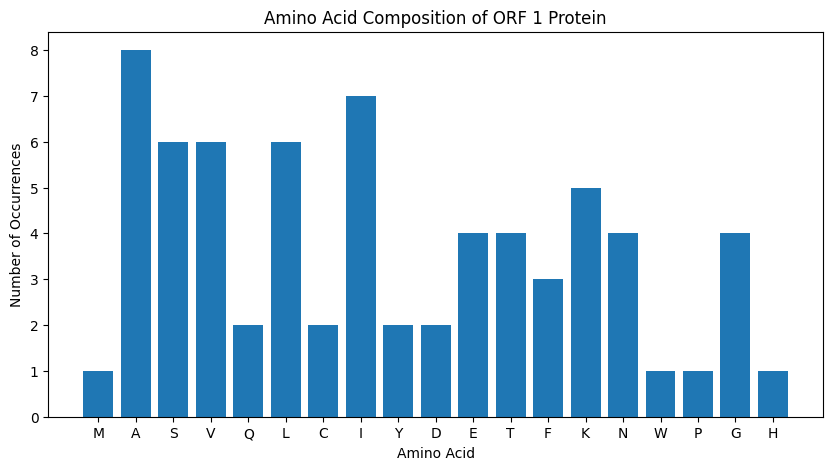

In [28]:
from collections import Counter
import matplotlib.pyplot as plt

protein = translate(orfs[0]["sequence"])

amino_acid_counts = Counter(protein)

plt.figure(figsize=(10, 5))
plt.bar(amino_acid_counts.keys(), amino_acid_counts.values())

plt.xlabel("Amino Acid")
plt.ylabel("Number of Occurrences")
plt.title("Amino Acid Composition of ORF 1 Protein")

plt.show()

# 🧬 Bioinformatics Sequence Analyzer

## Project Overview

This project is a Python-based bioinformatics tool for analyzing DNA sequences from FASTA files.

### Features
- FASTA sequence processing
- DNA sequence length and nucleotide composition
- Overall and window-based GC content analysis
- DNA motif searching
- Reverse complement generation
- Open Reading Frame (ORF) detection
- DNA-to-protein translation
- Amino-acid composition analysis
- Data visualization

### Objective

To develop a simple computational workflow for extracting and visualizing biological information from DNA sequences using Python.

### Technologies Used

- Python
- Google Colab
- Matplotlib
- FASTA sequence format

# 📊 Results

The Bioinformatics Sequence Analyzer was tested using a Homo sapiens DNA sequence in FASTA format.

### Sequence Analysis
- Sequence length: 125,833 bp
- Overall GC content: 44.10%
- Overall AT content: 55.90%

### Nucleotide Composition
The sequence was analyzed for the frequency of A, T, G and C nucleotides.

### GC Content Analysis
GC content was calculated in 1 kb windows to visualize variation across different regions of the sequence.

### Motif Analysis
The tool successfully searched for user-defined DNA motifs and reported their number of occurrences and positions.

### ORF Analysis
Potential Open Reading Frames were identified by detecting start codons followed by in-frame stop codons.

### Protein Analysis
Detected ORFs were translated into amino-acid sequences and their amino-acid composition was visualized.

# 🧬 Conclusion

The Bioinformatics Sequence Analyzer successfully processed a FASTA-format DNA sequence and extracted important sequence-level information.

The project demonstrates how Python can be used to perform basic bioinformatics tasks such as nucleotide composition analysis, GC-content analysis, motif searching, reverse-complement generation, ORF detection, DNA-to-protein translation, and amino-acid composition analysis.

This project provided practical experience in applying programming and computational methods to biological sequence data.

# ⚠️ Limitations and Future Improvements

### Current Limitations
- ORF detection is based on a simple start-codon/stop-codon approach.
- Protein translation currently uses the standard genetic code.
- The analyzer performs sequence-level analysis and does not identify gene function.

### Future Improvements
- Add BLAST-based similarity searching.
- Add protein property prediction.
- Add sequence alignment.
- Add an interactive user interface.
- Add automated biological annotation.